In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import os

DATA_DIR = '../数据'
df = pd.read_csv(os.path.join(DATA_DIR, 'processed_jobs.csv'))

feature_cols = ['经验年限_标准化', '学历编码_标准化', '规模编码_标准化', '薪资月数_标准化'] + \
               [c for c in df.columns if c.startswith('城市_')] + \
               [c for c in df.columns if c.startswith('行业分组_')] + \
               [c for c in df.columns if c.startswith('公司性质_')]

X = df[feature_cols]
y = df['月薪均值']
len(feature_cols)

38

In [2]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((1756, 38), (440, 38))

#### 一元线性回归基线模型（工作经验→薪资）

In [3]:
lr_simple = LinearRegression()
lr_simple.fit(X_train[['经验年限_标准化']], y_train)
pred_simple = lr_simple.predict(X_test[['经验年限_标准化']])

r2_simple = r2_score(y_test, pred_simple)
mae_simple = mean_absolute_error(y_test, pred_simple)
rmse_simple = mean_squared_error(y_test, pred_simple) ** 0.5
r2_simple, mae_simple, rmse_simple

(0.13077498891144224, 0.64300156733869, 0.8329300333501248)

#### 多元线性回归模型

In [4]:
lr_multi = LinearRegression()
lr_multi.fit(X_train, y_train)
pred_multi = lr_multi.predict(X_test)

r2_multi = r2_score(y_test, pred_multi)
mae_multi = mean_absolute_error(y_test, pred_multi)
rmse_multi = mean_squared_error(y_test, pred_multi) ** 0.5
r2_multi, mae_multi, rmse_multi

(0.33271748081009156, 0.5519905471934144, 0.7297889591405079)

In [5]:
results = {}
results['一元线性回归'] = {'R2': r2_simple, 'MAE': mae_simple, 'RMSE': rmse_simple}
results['多元线性回归'] = {'R2': r2_multi, 'MAE': mae_multi, 'RMSE': rmse_multi}
results

{'一元线性回归': {'R2': 0.13077498891144224,
  'MAE': 0.64300156733869,
  'RMSE': 0.8329300333501248},
 '多元线性回归': {'R2': 0.33271748081009156,
  'MAE': 0.5519905471934144,
  'RMSE': 0.7297889591405079}}

#### 随机森林回归模型

In [6]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

r2_rf = r2_score(y_test, pred_rf)
mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = mean_squared_error(y_test, pred_rf) ** 0.5
r2_rf, mae_rf, rmse_rf

(0.3769964368015053, 0.5313390644713758, 0.7051600178666368)

In [7]:
results['随机森林回归'] = {'R2': r2_rf, 'MAE': mae_rf, 'RMSE': rmse_rf}

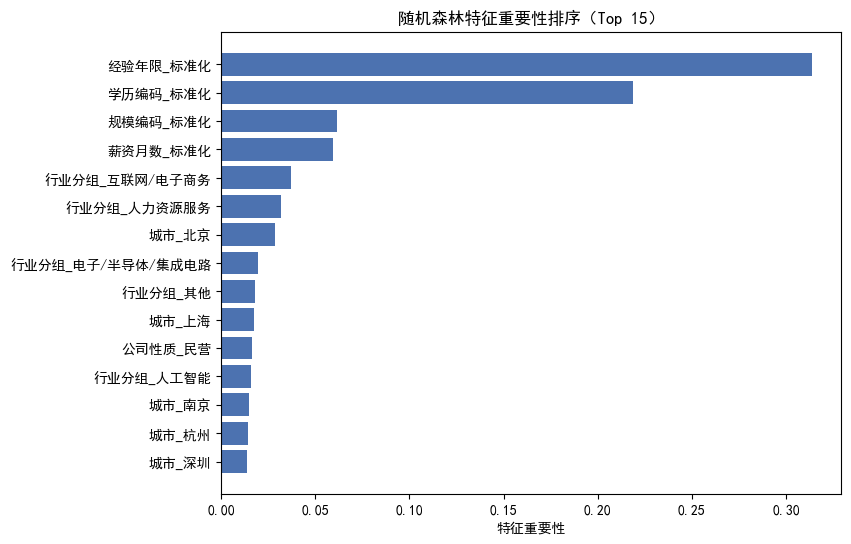

In [8]:
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

importance = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
plt.barh(importance.index[::-1], importance.values[::-1], color='#4C72B0')
plt.xlabel('特征重要性')
plt.title('随机森林特征重要性排序（Top 15）')
plt.show()

#### XGBoost回归模型

In [9]:
from xgboost import XGBRegressor

xgb_default = XGBRegressor(random_state=42)
xgb_default.fit(X_train, y_train)
pred_default = xgb_default.predict(X_test)
r2_score(y_test, pred_default)

0.2832146584523427

In [10]:
from sklearn.model_selection import GridSearchCV

param_grid = {'n_estimators': [100, 200], 'max_depth': [3, 5], 'learning_rate': [0.05, 0.1]}
grid_search = GridSearchCV(XGBRegressor(random_state=42), param_grid, cv=3, scoring='r2')
grid_search.fit(X_train, y_train)
grid_search.best_params_

{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}

In [11]:
xgb_best = grid_search.best_estimator_
pred_xgb = xgb_best.predict(X_test)

r2_xgb = r2_score(y_test, pred_xgb)
mae_xgb = mean_absolute_error(y_test, pred_xgb)
rmse_xgb = mean_squared_error(y_test, pred_xgb) ** 0.5
r2_xgb, mae_xgb, rmse_xgb

(0.3862835809251235, 0.5340103314916292, 0.6998843557303706)

In [12]:
results['XGBoost回归'] = {'R2': r2_xgb, 'MAE': mae_xgb, 'RMSE': rmse_xgb}

#### 模型对比总结

In [13]:
results_df = pd.DataFrame(results).T.round(4)
results_df

,R2,MAE,RMSE
一元线性回归,0.1308,0.6430,0.8329
多元线性回归,0.3327,0.5520,0.7298
随机森林回归,0.3770,0.5313,0.7052
XGBoost回归,0.3863,0.5340,0.6999
